In [ ]:
%matplotlib inline

import yaml
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

CONFIGS_DIR = Path('../configs').resolve()
ARTIFACTS_ROOT = Path('../artifacts').resolve()
FIGURES_EDA = ARTIFACTS_ROOT / 'figures' / 'eda'

for p in [CONFIGS_DIR, FIGURES_EDA]:
    p.mkdir(parents=True, exist_ok=True)

def setup_logger(log_path: str, name: str = "eda"):
    logger = logging.getLogger(name)
    logger.handlers.clear()
    logger.setLevel(logging.INFO)
    logger.propagate = False
    fmt = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
    sh = logging.StreamHandler()
    sh.setFormatter(fmt)
    logger.addHandler(sh)
    fh = logging.FileHandler(log_path, mode='w', encoding='utf-8')
    fh.setFormatter(fmt)
    logger.addHandler(fh)
    return logger

logger = setup_logger(str(ARTIFACTS_ROOT / "logs" / 'eda.log'))
logger.info('EDA logger initialized')

data_config = {
    'source_path': '../data/ENB2012_data.csv',
    'separator': ';',
    'decimal': ',',
    'dropna_how': 'all',
    'columns': {
        'numeric': ['X1', 'X2', 'X3', 'X4', 'X5', 'X7'],
        'categorical': ['X6', 'X8'],
        'targets': ['Y1', 'Y2']
    }
}
with open(CONFIGS_DIR / 'data.yaml', 'w', encoding='utf-8') as f:
    yaml.safe_dump(data_config, f, default_flow_style=False, allow_unicode=True)

env_example = (
    "# Переменные окружения (не коммитить!)\n"
    "ARTIFACTS_PATH=./artifacts\n"
    "CONFIGS_PATH=./configs\n"
    "LOG_LEVEL=info\n"
)
with open(CONFIGS_DIR / '.env.example', 'w', encoding='utf-8') as f:
    f.write(env_example)

logger.info('Конфигурации и .env.example сохранены в configs/')

with open(CONFIGS_DIR / 'data.yaml', 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

def save_and_show(fig, name, output_dir):
    plt.show()
    filepath = output_dir / f'{name}.png'
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close(fig)
    logger.info(f'График сохранён: {filepath}')
    return filepath

2026-05-21 09:31:45,073 - INFO - EDA logger initialized
2026-05-21 09:31:45,080 - INFO - Конфигурации и .env.example сохранены в configs/


In [2]:
df = pd.read_csv(
    cfg['source_path'],
    sep=cfg['separator'],
    decimal=cfg['decimal']
)
df = df.dropna(how=cfg['dropna_how']).reset_index(drop=True)

num_cols = cfg['columns']['numeric']
cat_cols = cfg['columns']['categorical']
target_cols = cfg['columns']['targets']

df[cat_cols] = df[cat_cols].astype('category')

logger.info(f'Данные загружены: {df.shape}')
print(f'Размер данных: {df.shape}')
print(f'Столбцы: {list(df.columns)}')
print('\nПервые 5 строк:')
display(df.head())

print('\nИнформация о типах данных (df.info()):')
print(df.info())

print('\nБазовая статистика (df.describe()):')
display(df.describe().T)

2026-05-21 09:31:45,167 - INFO - Данные загружены: (768, 10)


Размер данных: (768, 10)
Столбцы: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2']

Первые 5 строк:


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.9800,514.5000,294.0000,110.2500,7.0000,2,0.0000,0,15.5500,21.3300
1,0.9800,514.5000,294.0000,110.2500,7.0000,3,0.0000,0,15.5500,21.3300
2,0.9800,514.5000,294.0000,110.2500,7.0000,4,0.0000,0,15.5500,21.3300
3,0.9800,514.5000,294.0000,110.2500,7.0000,5,0.0000,0,15.5500,21.3300
4,0.9000,563.5000,318.5000,122.5000,7.0000,2,0.0000,0,20.8400,28.2800



Информация о типах данных (df.info()):
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   X1      768 non-null    float64 
 1   X2      768 non-null    float64 
 2   X3      768 non-null    float64 
 3   X4      768 non-null    float64 
 4   X5      768 non-null    float64 
 5   X6      768 non-null    category
 6   X7      768 non-null    float64 
 7   X8      768 non-null    category
 8   Y1      768 non-null    float64 
 9   Y2      768 non-null    float64 
dtypes: category(2), float64(8)
memory usage: 49.7 KB
None

Базовая статистика (df.describe()):


,count,mean,std,min,25%,50%,75%,max
X1,768.0000,0.7642,0.1058,0.6200,0.6825,0.7500,0.8300,0.9800
X2,768.0000,671.7083,88.0861,514.5000,606.3750,673.7500,741.1250,808.5000
X3,768.0000,318.5000,43.6265,245.0000,294.0000,318.5000,343.0000,416.5000
X4,768.0000,176.6042,45.1660,110.2500,140.8750,183.7500,220.5000,220.5000
X5,768.0000,5.2500,1.7511,3.5000,3.5000,5.2500,7.0000,7.0000
X7,768.0000,0.2344,0.1332,0.0000,0.1000,0.2500,0.4000,0.4000
Y1,768.0000,22.3072,10.0902,6.0100,12.9925,18.9500,31.6675,43.1000
Y2,768.0000,24.5878,9.5133,10.9000,15.6200,22.0800,33.1325,48.0300


In [3]:
missing = df.isna().sum()
duplicates = df.duplicated().sum()

logger.info(f'Пропуски: {missing.sum()}, Дубликаты: {duplicates}')
print(f'Всего пропусков: {missing.sum()}')
print(f'Полные дубликаты строк: {duplicates}')
if missing.sum() == 0 and duplicates == 0:
    print('Данные чистые: пропусков и дубликатов нет')

2026-05-21 09:31:45,534 - INFO - Пропуски: 0, Дубликаты: 0


Всего пропусков: 0
Полные дубликаты строк: 0
Данные чистые: пропусков и дубликатов нет


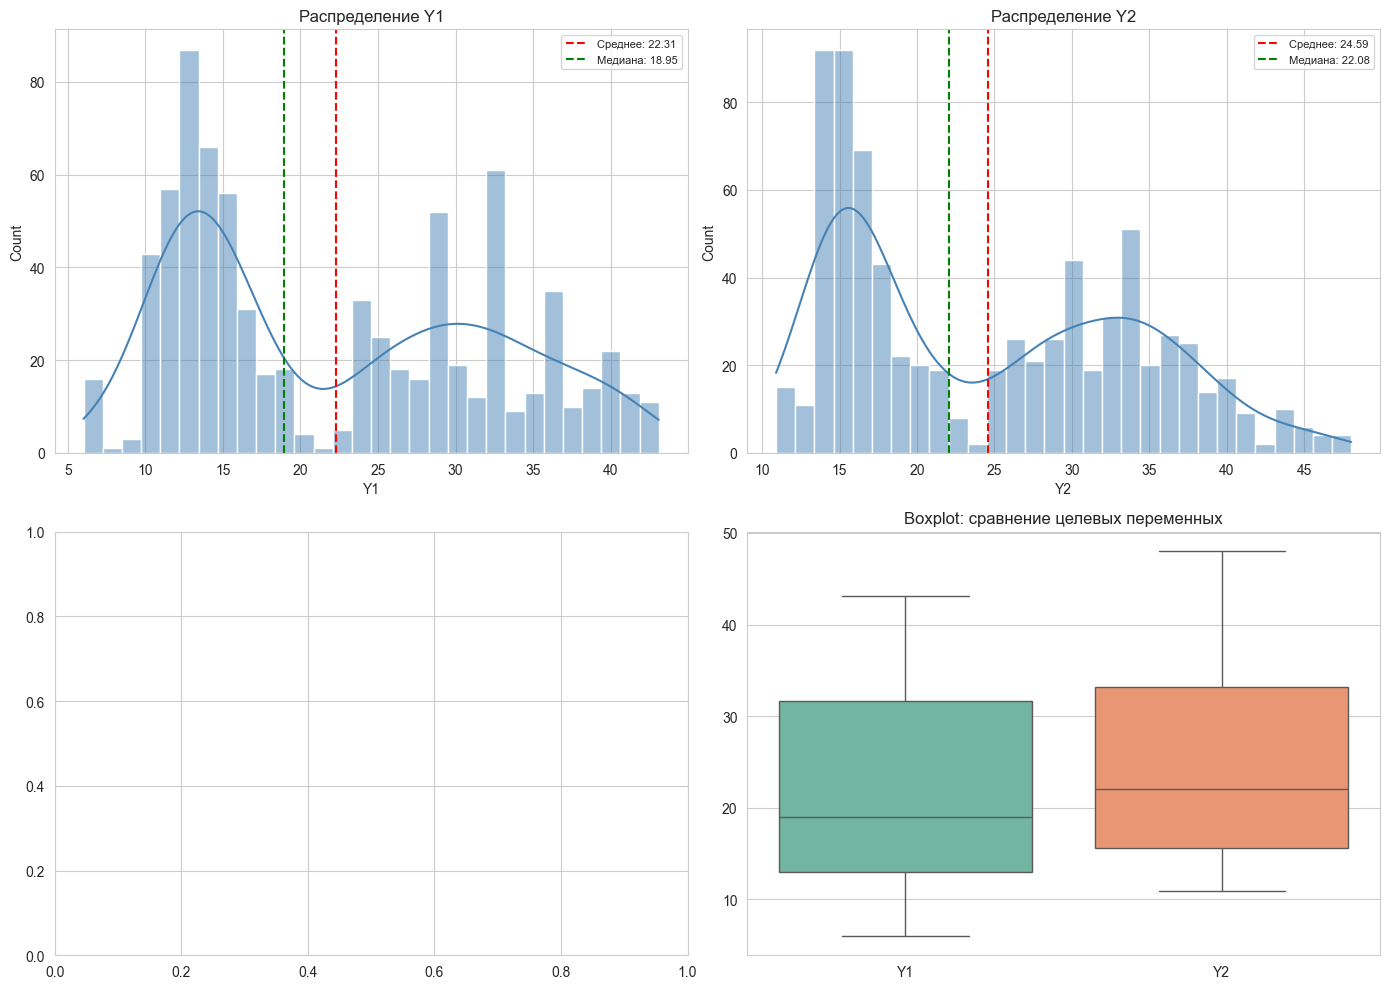

2026-05-21 09:31:47,971 - INFO - График сохранён: C:\ИИИ\AIE\project\artifacts\figures\eda\target_distributions.png


WindowsPath('C:/ИИИ/AIE/project/artifacts/figures/eda/target_distributions.png')

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, target in enumerate(target_cols):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    sns.histplot(df[target], bins=30, kde=True, ax=ax, color='steelblue')
    ax.axvline(df[target].mean(), color='red', linestyle='--', label=f'Среднее: {df[target].mean():.2f}')
    ax.axvline(df[target].median(), color='green', linestyle='--', label=f'Медиана: {df[target].median():.2f}')
    ax.set_title(f'Распределение {target}')
    ax.legend(fontsize=8)

ax = axes[1, 1]
sns.boxplot(data=df[target_cols], ax=ax, palette='Set2')
ax.set_title('Boxplot: сравнение целевых переменных')

plt.tight_layout()
save_and_show(fig, 'target_distributions', FIGURES_EDA)

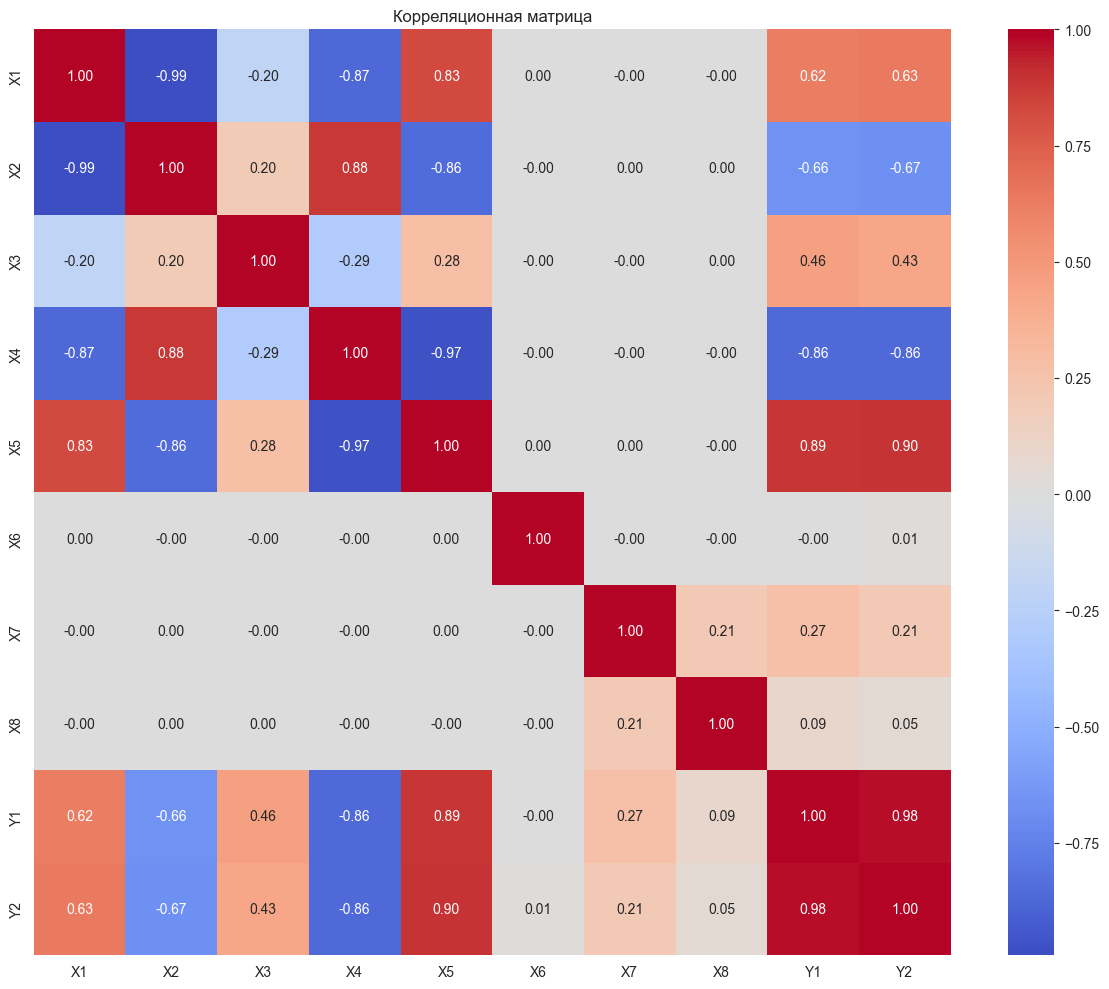

2026-05-21 09:31:49,500 - INFO - График сохранён: C:\ИИИ\AIE\project\artifacts\figures\eda\correlation_matrix.png
2026-05-21 09:31:49,504 - INFO - Топ-корреляции с целевыми переменными:



Топ-корреляции:
Y1: {'X5': np.float64(0.889), 'X4': np.float64(0.862), 'X2': np.float64(0.658)}
Y2: {'X5': np.float64(0.896), 'X4': np.float64(0.863), 'X2': np.float64(0.673)}


In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.tight_layout()
save_and_show(plt.gcf(), 'correlation_matrix', FIGURES_EDA)

logger.info('Топ-корреляции с целевыми переменными:')
print('\nТоп-корреляции:')
for target in target_cols:
    top = df.corr()[target].drop(target_cols).abs().nlargest(3)
    print(f'{target}: {dict(zip(top.index, top.values.round(3)))}')

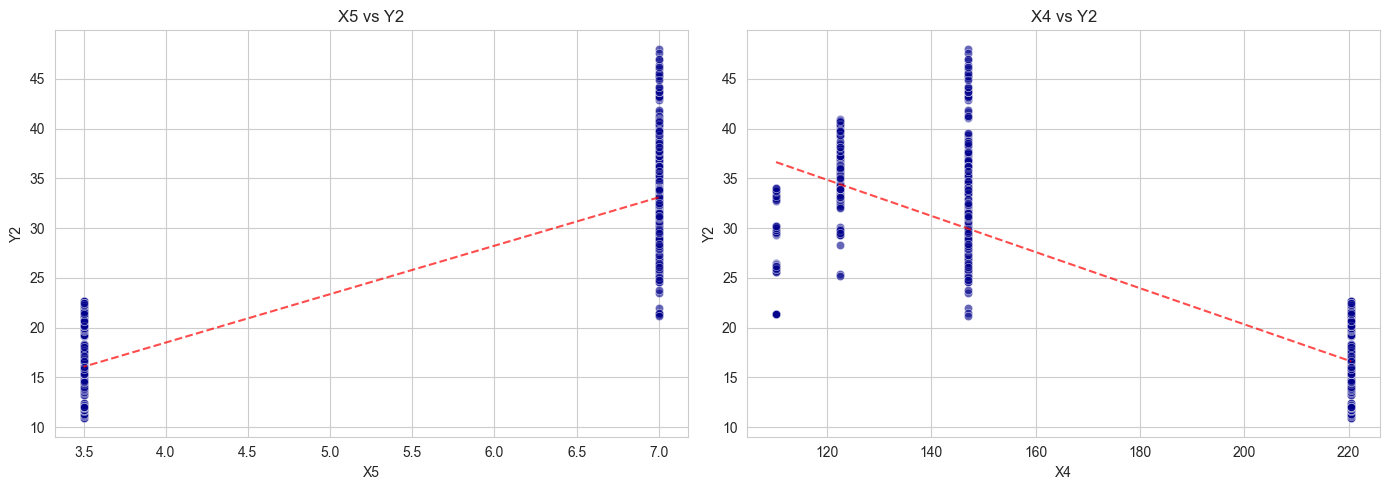

2026-05-21 09:31:52,019 - INFO - График сохранён: C:\ИИИ\AIE\project\artifacts\figures\eda\top_features_vs_Y2.png


WindowsPath('C:/ИИИ/AIE/project/artifacts/figures/eda/top_features_vs_Y2.png')

In [6]:
target = 'Y2'
top_features = df.corr()[target].drop(target_cols).abs().nlargest(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top_features):
    sns.scatterplot(x=df[feat], y=df[target], alpha=0.6, ax=ax, color='darkblue')
    z = np.polyfit(df[feat], df[target], 1)
    p = np.poly1d(z)
    ax.plot(df[feat], p(df[feat]), 'r--', alpha=0.7)
    ax.set_title(f'{feat} vs {target}')
plt.tight_layout()
save_and_show(fig, 'top_features_vs_Y2', FIGURES_EDA)

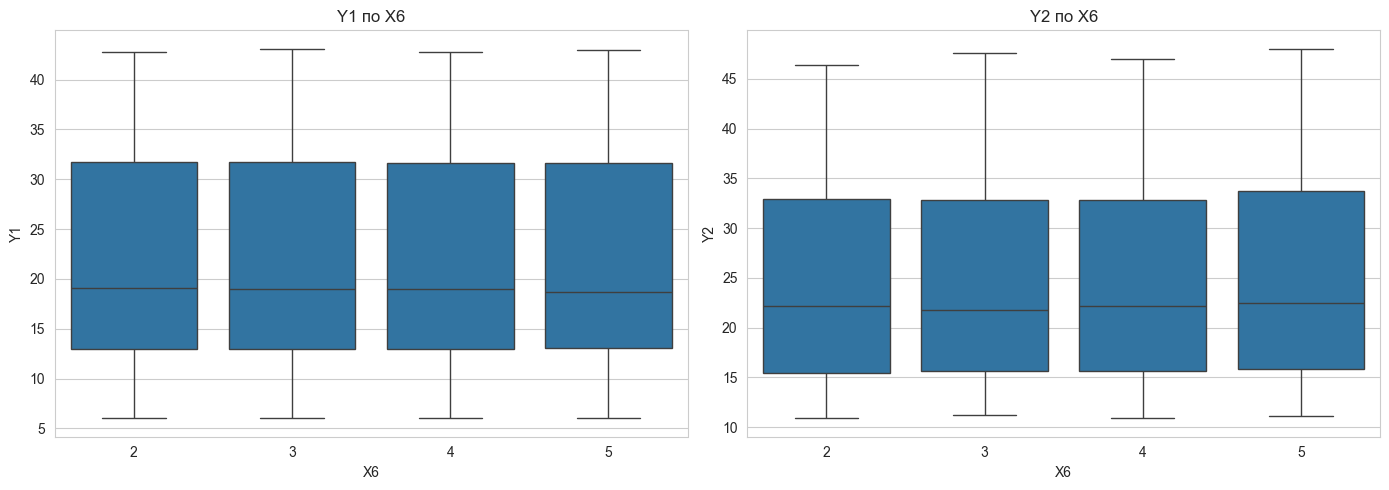

2026-05-21 09:31:53,558 - INFO - График сохранён: C:\ИИИ\AIE\project\artifacts\figures\eda\X6_boxplots.png


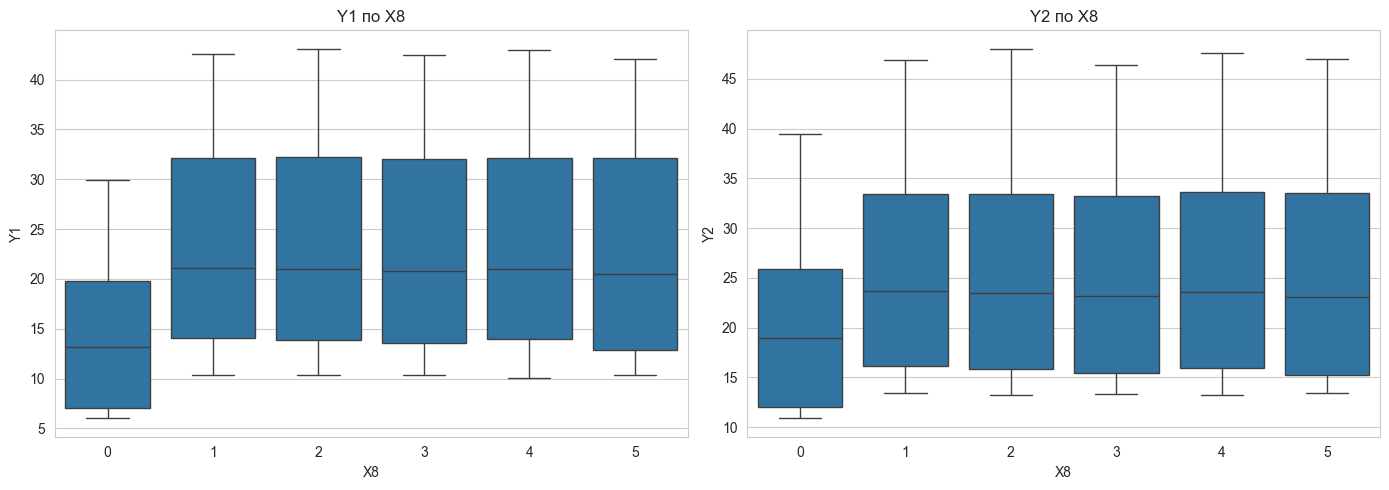

2026-05-21 09:31:54,824 - INFO - График сохранён: C:\ИИИ\AIE\project\artifacts\figures\eda\X8_boxplots.png


In [7]:
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, t in zip(axes, target_cols):
        sns.boxplot(x=col, y=t, data=df, ax=ax)
        ax.set_title(f'{t} по {col}')
    plt.tight_layout()
    save_and_show(fig, f'{col}_boxplots', FIGURES_EDA)

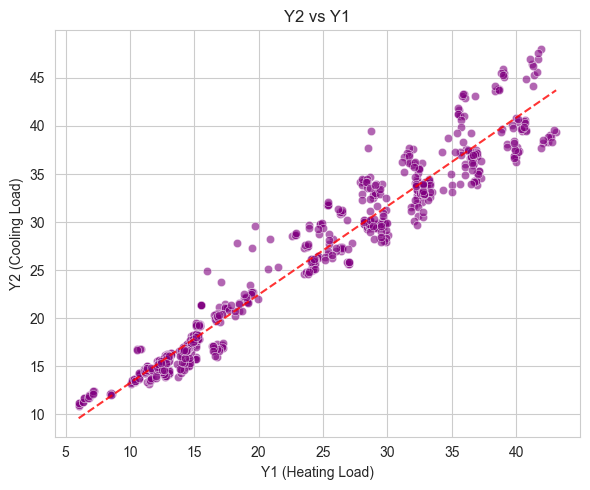

2026-05-21 09:31:57,598 - INFO - График сохранён: C:\ИИИ\AIE\project\artifacts\figures\eda\Y1_vs_Y2.png


WindowsPath('C:/ИИИ/AIE/project/artifacts/figures/eda/Y1_vs_Y2.png')

In [8]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x='Y1', y='Y2', data=df, alpha=0.6, color='purple')
plt.title('Y2 vs Y1')
plt.xlabel('Y1 (Heating Load)')
plt.ylabel('Y2 (Cooling Load)')
z = np.polyfit(df['Y1'], df['Y2'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Y1'].min(), df['Y1'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', alpha=0.8)
plt.tight_layout()
save_and_show(plt.gcf(), 'Y1_vs_Y2', FIGURES_EDA)

In [9]:
logger.info('EDA завершено')
print('\nИтоговые выводы по EDA:')
print('1. Пропусков и дубликатов нет.')
print(f'2. Y1 и Y2 коррелируют: {df["Y1"].corr(df["Y2"]):+.3f}.')
print(f'3. Топ-предикторы для Y2: {", ".join(df.corr()["Y2"].drop(target_cols).abs().nlargest(3).index.tolist())}.')
print('4. Категориальные признаки показывают различия между группами.')
print(f'5. Все графики сохранены в: {FIGURES_EDA}')

2026-05-21 09:31:57,945 - INFO - EDA завершено



Итоговые выводы по EDA:
1. Пропусков и дубликатов нет.
2. Y1 и Y2 коррелируют: +0.976.
3. Топ-предикторы для Y2: X5, X4, X2.
4. Категориальные признаки показывают различия между группами.
5. Все графики сохранены в: C:\ИИИ\AIE\project\artifacts\figures\eda


In [10]:
print('Проверка воспроизводимости:')
print(f'Размер данных: {df.shape}')
print(f'Пропуски: {df.isna().sum().sum()}')
print(f'Дубликаты: {df.duplicated().sum()}')
for target in target_cols:
    print(f'{target}: диапазон [{df[target].min():.2f}, {df[target].max():.2f}]')
print(f'Создано фигур: {len(list(FIGURES_EDA.glob("*.png")))}')
print('EDA завершено.')

Проверка воспроизводимости:
Размер данных: (768, 10)
Пропуски: 0
Дубликаты: 0
Y1: диапазон [6.01, 43.10]
Y2: диапазон [10.90, 48.03]
Создано фигур: 6
EDA завершено.
